In [90]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

ATTACK_METHOD = "pgd"  # Change to "pgd" or other methods
DATASET_NAME = "taiwan_bankruptcy"
ALPHA = 0.005
EPSILON = 0.02
MAXITERS = 100
ATTACK_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]

# DATA_DIR = Path('spambase_50_50')
if DATASET_NAME == "spambase":
    DATA_DIR = Path('/home/skada009/aro/spambase_10_40_50')
    SCORES_DIR = Path('/home/skada009/aro/experiments/noise_scoring_outputs/20260324_203954')
    MLP = 'spambase_mlp.pth'
else:
    DATA_DIR = Path('/home/skada009/aro/taiwan_bankruptcy_10_40_50')
    SCORES_DIR = Path('/home/skada009/aro/experiments/noise_scoring_outputs/taiwan_bankruptcy/20260514_161236')
    MLP = 'taiwan_bankruptcy_mlp.pth'
    print(f"Using dataset: {DATASET_NAME}")

if ATTACK_METHOD == "pgd" or ATTACK_METHOD == "fgsm":
    OUTPUT_DIR = Path(f'/home/skada009/aro/experiments/final_notebooks/results/{DATASET_NAME}/{ATTACK_METHOD}_{EPSILON}')
    PREV_RESULTS_DIR = Path(f'/home/skada009/aro/experiments/final_notebooks/results/{DATASET_NAME}/{ATTACK_METHOD}_{EPSILON}')
elif ATTACK_METHOD == "deepfool":
    OUTPUT_DIR = Path(f'/home/skada009/aro/experiments/final_notebooks/results/{DATASET_NAME}/{ATTACK_METHOD}_{ALPHA}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
GPU: NVIDIA RTX A6000
Using dataset: taiwan_bankruptcy


In [91]:
data = np.load(DATA_DIR / 'train_test_data.npz')
print(len(data['X_train']), len(data['y_train']), len(data['X_test']), len(data['y_test']))
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape

prep = np.load(DATA_DIR / 'preprocessing.npz')
weights = prep['weights']
bounds = [prep['bounds_min'], prep['bounds_max']]


class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)

class BankruptcyNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)
    
checkpoint = torch.load(DATA_DIR / MLP, map_location=device)
if DATASET_NAME == "spambase":
    model = SpambaseNet(D_in=57).to(device)
else:
    model = BankruptcyNet(checkpoint['D_in']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f'Test set: {n_test} samples, {n_features} features')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')

print(f"✓ Model loaded | Train Acc: {checkpoint.get('train_accuracy', 'N/A')}, Test Acc: {checkpoint.get('test_accuracy', 'N/A')}")

print("Loading test data...")
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test'].astype(np.int64)
print(f"✓ Test set: {X_test.shape}")

print("Loading preprocessing parameters...")
weights = prep['weights'].astype(np.float32)
bounds_min = prep['bounds_min'].astype(np.float32)
bounds_max = prep['bounds_max'].astype(np.float32)
bounds = [bounds_min, bounds_max]
print(f"✓ Bounds: [{bounds_min.min():.4f}, {bounds_max.max():.4f}], Weights shape: {weights.shape}")


2727 2727 3410 3410
Test set: 3410 samples, 94 features
Correctly classified: 2998/3410 (87.92%)
✓ Model loaded | Train Acc: 0.8888888888888888, Test Acc: 0.8791788856304985
Loading test data...
✓ Test set: (3410, 94)
Loading preprocessing parameters...
✓ Bounds: [0.0000, 1.0000], Weights shape: (94,)


In [92]:

score1_removal_order = np.load(f'{SCORES_DIR}/test_clean_data_score1_removed_index.npy').astype(int)
score2_value = np.load(f'{SCORES_DIR}/test_clean_data_score2_noise_scores.npy')

# Noisiest-first orderings, filtered to correctly-classified only
score1_order = [idx for idx in score1_removal_order if correct_mask[idx]]
score2_order = [idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]]

score_orders = {'Score 1': score1_order, 'Score 2': score2_order}
print(f'Eligible points per score ordering: {len(score1_order)}')

Eligible points per score ordering: 2998


In [93]:
# Import attack methods
from utils.fgsm import create_fgsm, fgsm_attack

# Create attack instance
if ATTACK_METHOD == "fgsm":
    wrapped_model, attack_obj = create_fgsm(model, bounds_min, bounds_max, eps=EPSILON)
    attack_func = fgsm_attack
    
elif ATTACK_METHOD == "pgd":
    from utils.pgd_attack import create_pgd, pgd_attack
    wrapped_model, attack_obj = create_pgd(model, bounds_min, bounds_max, MAXITERS, eps=EPSILON)
    attack_func = pgd_attack

elif ATTACK_METHOD == "deepfool":
    from utils.deepfool import deepfool
    wrapped_model, attack_obj = None, None
    print(ALPHA)
    def deepfool_attack(x_sample, model, _attack_obj, device):
        # deepfool expects a torch Tensor sample
        x_t = torch.FloatTensor(x_sample).to(device)
        y_orig, y_adv, x_adv, _ = deepfool(
            x_t, model,
            maxiters=MAXITERS, alpha=ALPHA,
            bounds=bounds, weights=[],
        )
        return int(y_orig), int(y_adv), x_adv

    attack_func = deepfool_attack

else:
    raise ValueError(f"Unknown ATTACK_METHOD={ATTACK_METHOD!r}")

print(f"✓ Attack method: {ATTACK_METHOD.upper()}")


✓ Attack method: PGD


In [94]:
print(f'\n{"="*50}')
print(f"GENERATING ADVERSARIAL SAMPLES ({ATTACK_METHOD})")
print(f'{"="*50}')

X_adv = np.copy(X_test)
attack_success = np.zeros(n_test, dtype=int)
t0 = time.time()

for i, idx in enumerate(correct_indices):
    x = torch.FloatTensor(X_test[idx]).to(device)
    y_orig_i, y_adv_i, x_adv_i = attack_func(X_test[idx], model, attack_obj, device)
    
    X_adv[idx] = x_adv_i
    attack_success[idx] = 1 if y_orig_i != y_adv_i else 0

    if (i + 1) % 200 == 0 or i == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (n_correct - i - 1)
        n_succ = attack_success[correct_indices[:i+1]].sum()
        print(f'  [{i+1:>4d}/{n_correct}] success so far: {n_succ}/{i+1} | ETA: {eta:.0f}s')

n_succ = attack_success[correct_indices].sum()
print(f'  Done: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) | {time.time()-t0:.1f}s')

np.savez_compressed(
    OUTPUT_DIR / 'adversarial_samples.npz',
    **{f'X_adv_{ATTACK_METHOD}': X_adv, f'success_{ATTACK_METHOD}': attack_success}
)
print('\nAdversarial samples saved to', OUTPUT_DIR / 'adversarial_samples.npz')


GENERATING ADVERSARIAL SAMPLES (pgd)


PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  [   1/2998] success so far: 1/1 | ETA: 1123s


PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Done: 1906/2998 (63.58%) | 1229.4s

Adversarial samples saved to /home/skada009/aro/experiments/final_notebooks/results/taiwan_bankruptcy/pgd_0.02/adversarial_samples.npz


In [95]:
print(f'\n{"="*50}')
print(f'  ASR Check Before Vaccination')
print(f'{"="*50}')
n_succ = attack_success[correct_indices].sum()
print(f'{ATTACK_METHOD.upper()}: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) attacks succeeded')


  ASR Check Before Vaccination
PGD: 1906/2998 (63.58%) attacks succeeded


In [96]:
# Compute perturbation metrics (X_adv vs X_test) and save to a text file

Xo = X_test.astype(np.float32)
Xa = X_adv.astype(np.float32)

delta = (Xa - Xo)
abs_delta = np.abs(delta)

# Per-sample metrics of the perturbation delta
mae = abs_delta.mean(axis=1)
rmse = np.sqrt((delta ** 2).mean(axis=1))
l1 = abs_delta.sum(axis=1)
l2 = np.sqrt((delta ** 2).sum(axis=1))
linf = abs_delta.max(axis=1)

# Per-sample metrics of the original and perturbed samples themselves
abs_Xo = np.abs(Xo)
abs_Xa = np.abs(Xa)

orig_mae = abs_Xo.mean(axis=1)
adv_mae = abs_Xa.mean(axis=1)
orig_rmse = np.sqrt((Xo ** 2).mean(axis=1))
adv_rmse = np.sqrt((Xa ** 2).mean(axis=1))
orig_l1 = abs_Xo.sum(axis=1)
adv_l1 = abs_Xa.sum(axis=1)
orig_l2 = np.sqrt((Xo ** 2).sum(axis=1))
adv_l2 = np.sqrt((Xa ** 2).sum(axis=1))
orig_linf = abs_Xo.max(axis=1)
adv_linf = abs_Xa.max(axis=1)

idx_correct = correct_indices
idx_succ = idx_correct[attack_success[idx_correct] == 1]

asr = float(attack_success[idx_correct].mean()) if len(idx_correct) else 0.0
n_succ = int(attack_success[idx_correct].sum())

# Sanity checks: did X actually change?
changed_mask = np.any(abs_delta > 0, axis=1)
n_changed_correct = int(np.sum(changed_mask[idx_correct])) if len(idx_correct) else 0
n_changed_succ = int(np.sum(changed_mask[idx_succ])) if len(idx_succ) else 0
max_abs_delta_correct = float(np.max(abs_delta[idx_correct])) if len(idx_correct) else 0.0
max_abs_delta_succ = float(np.max(abs_delta[idx_succ])) if len(idx_succ) else 0.0


def _stats(x, idx):
    if len(idx) == 0:
        return {'count': 0, 'mean': np.nan, 'median': np.nan, 'min': np.nan, 'max': np.nan}
    v = x[idx]
    return {
        'count': int(len(idx)),
        'mean': float(np.mean(v)),
        'median': float(np.median(v)),
        'min': float(np.min(v)),
        'max': float(np.max(v)),
    }


def _compare_stats(orig, adv, idx):
    # Returns summary showing why orig/adv can look the same (tiny deltas).
    if len(idx) == 0:
        return {'orig_mean': np.nan, 'adv_mean': np.nan, 'mean_abs_diff': np.nan, 'max_abs_diff': np.nan}
    o = orig[idx]
    a = adv[idx]
    d = np.abs(a - o)
    return {
        'orig_mean': float(np.mean(o)),
        'adv_mean': float(np.mean(a)),
        'mean_abs_diff': float(np.mean(d)),
        'max_abs_diff': float(np.max(d)),
    }


report_path = OUTPUT_DIR / f'attack_metrics_{ATTACK_METHOD}.txt'
with open(report_path, 'w') as f:
    f.write("Attack metrics report\n")
    f.write(f"Dataset: {DATASET_NAME}\n")
    f.write(f"Attack: {ATTACK_METHOD}\n")
    if ATTACK_METHOD == 'deepfool':
        f.write(f"alpha={ALPHA}, maxiters={MAXITERS}\n")
    else:
        f.write(f"epsilon={EPSILON}\n")
    f.write("\n")

    f.write(f"Correctly-classified originals: {len(idx_correct)}/{n_test}\n")
    f.write(f"Successfully attacked (among correct): {n_succ}/{len(idx_correct)}\n")
    f.write(f"ASR (among correct): {asr:.4f}\n")
    f.write("\n")

    f.write(f"Changed samples among correct (any feature changed): {n_changed_correct}/{len(idx_correct)}\n")
    f.write(f"Max |delta| among correct: {max_abs_delta_correct:.6g}\n")
    f.write("\n")
    f.write(f"Changed samples among successful attacks: {n_changed_succ}/{len(idx_succ)}\n")
    f.write(f"Max |delta| among successful attacks: {max_abs_delta_succ:.6g}\n")

    f.write("\nSummary of perturbation size (delta = X_adv - X_test) over correctly-classified originals\n")
    for name, arr in [('MAE', mae), ('RMSE', rmse), ('L1', l1), ('L2', l2), ('Linf', linf)]:
        s = _stats(arr, idx_correct)
        f.write(f"  {name:5s}: mean={s['mean']:.6g} median={s['median']:.6g} min={s['min']:.6g} max={s['max']:.6g}\n")

    f.write("\nOriginal vs Perturbed (these can look very similar if delta is small)\n")
    f.write("Subset: correctly-classified originals\n")
    for name, o, a in [
        ('MAE', orig_mae, adv_mae),
        ('RMSE', orig_rmse, adv_rmse),
        ('L1', orig_l1, adv_l1),
        ('L2', orig_l2, adv_l2),
        ('Linf', orig_linf, adv_linf),
    ]:
        c = _compare_stats(o, a, idx_correct)
        f.write(f"  {name:5s}: orig_mean={c['orig_mean']:.6g} adv_mean={c['adv_mean']:.6g} mean|diff|={c['mean_abs_diff']:.6g} max|diff|={c['max_abs_diff']:.6g}\n")

    f.write("\nSubset: successfully-attacked (among correct)\n")
    for name, o, a in [
        ('MAE', orig_mae, adv_mae),
        ('RMSE', orig_rmse, adv_rmse),
        ('L1', orig_l1, adv_l1),
        ('L2', orig_l2, adv_l2),
        ('Linf', orig_linf, adv_linf),
    ]:
        c = _compare_stats(o, a, idx_succ)
        f.write(f"  {name:5s}: orig_mean={c['orig_mean']:.6g} adv_mean={c['adv_mean']:.6g} mean|diff|={c['mean_abs_diff']:.6g} max|diff|={c['max_abs_diff']:.6g}\n")

    f.write("\nPer-sample details (correctly-classified originals)\n")
    f.write("idx,attack_success,changed,mae_delta,rmse_delta,l1_delta,l2_delta,linf_delta\n")
    for idx in idx_correct:
        f.write(
            f"{int(idx)},{int(attack_success[idx])},{int(changed_mask[idx])},{mae[idx]:.6g},{rmse[idx]:.6g},{l1[idx]:.6g},{l2[idx]:.6g},{linf[idx]:.6g}\n"
        )

print('Saved attack metrics report to', report_path)
print('ASR (among correct):', f'{asr:.2%}')
print('Changed samples among correct:', f'{n_changed_correct}/{len(idx_correct)}')
print('Max |delta| among correct:', f'{max_abs_delta_correct:.6g}')

print('Perturbation size (delta) over correctly-classified:')
print(f"  MAE(delta):  {np.mean(mae[idx_correct]):.6g} (mean), {np.median(mae[idx_correct]):.6g} (median)")
print(f"  RMSE(delta): {np.mean(rmse[idx_correct]):.6g} (mean), {np.median(rmse[idx_correct]):.6g} (median)")
print(f"  L2(delta):   {np.mean(l2[idx_correct]):.6g} (mean), {np.median(l2[idx_correct]):.6g} (median)")

print('Original vs perturbed summary (means over correctly-classified):')
print(f"  L2(x):  orig_mean={np.mean(orig_l2[idx_correct]):.6g}  adv_mean={np.mean(adv_l2[idx_correct]):.6g}  mean|diff|={np.mean(np.abs(adv_l2[idx_correct]-orig_l2[idx_correct])):.6g}")
print(f"  Linf(x): orig_mean={np.mean(orig_linf[idx_correct]):.6g}  adv_mean={np.mean(adv_linf[idx_correct]):.6g}  mean|diff|={np.mean(np.abs(adv_linf[idx_correct]-orig_linf[idx_correct])):.6g}")

Saved attack metrics report to /home/skada009/aro/experiments/final_notebooks/results/taiwan_bankruptcy/pgd_0.02/attack_metrics_pgd.txt
ASR (among correct): 63.58%
Changed samples among correct: 2998/2998
Max |delta| among correct: 0.02
Perturbation size (delta) over correctly-classified:
  MAE(delta):  0.016513 (mean), 0.0164766 (median)
  RMSE(delta): 0.0181213 (mean), 0.0181119 (median)
  L2(delta):   0.175692 (mean), 0.175602 (median)
Original vs perturbed summary (means over correctly-classified):
  L2(x):  orig_mean=4.36393  adv_mean=4.38154  mean|diff|=0.0191915
  Linf(x): orig_mean=0.999071  adv_mean=0.999508  mean|diff|=0.00135497


In [97]:
def vaccinate_and_classify(X_mixed, k, model, device):
    """Apply k-rank SVD approximation, clip to [0,1], classify with model."""
    U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)
    X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
    X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
    with torch.no_grad():
        preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()
    return preds


rows = []
t_total = time.time()

for score_name, order in score_orders.items():
    n_eligible = len(order)
    for attack_pct in ATTACK_PCTS:
        n_attack = max(1, int(n_eligible * attack_pct / 100))

        # Noisy tier: first n_attack in noisiest-first order
        noisy_indices = order[:n_attack]
        # Structural tier: last n_attack in noisiest-first order (most structural)
        structural_indices = order[-n_attack:]

        for tier_name, tier_idx in [('structural', structural_indices), ('noisy', noisy_indices)]:
            # Construct mixed matrix: replace targeted tier with adversarial versions
            X_mixed = np.copy(X_test)
            n_successfully_attacked = 0
            for idx in tier_idx:
                if attack_success[idx]:
                    X_mixed[idx] = X_adv[idx]
                    n_successfully_attacked += 1

            # Calculate ASR before vaccination
            asr_before = n_successfully_attacked / len(tier_idx) if len(tier_idx) > 0 else 0.0

            if n_successfully_attacked == 0:
                for k in K_RANKS:
                    rows.append({
                        'score_type': score_name, 'tier': tier_name,
                        'attack_pct': attack_pct, 'k': k,
                        'n_targeted': len(tier_idx), 'n_attacked': 0,
                        'restoration_rate': 0.0, 'asr_after': 0.0,
                        'asr_before': asr_before,
                    })
                continue
            print(f'\n{score_name} | {tier_name} tier | attack_pct={attack_pct}% | targeted {len(tier_idx)}, successfully attacked {n_successfully_attacked}')
            print("ASR before vaccination: {:.2%}".format(asr_before))
            # Single SVD, then evaluate at each k
            U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)

            for k in K_RANKS:
                X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
                X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
                with torch.no_grad():
                    preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()

                n_restored = sum(
                    1 for idx in tier_idx
                    if attack_success[idx] and preds[idx] == y_test[idx]
                )
                restoration_rate = n_restored / n_successfully_attacked

                rows.append({
                    'score_type': score_name, 'tier': tier_name,
                    'attack_pct': attack_pct, 'k': k,
                    'n_targeted': len(tier_idx), 'n_attacked': n_successfully_attacked,
                    'restoration_rate': restoration_rate, 'asr_after': 1 - restoration_rate,
                    'asr_before': asr_before,
                })

        print(f'{score_name} | attack_pct={attack_pct:>3d}% done ({time.time()-t_total:.1f}s)')

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'vaccination_sweep.csv', index=False)
print(f'\nSweep complete: {len(df)} rows, saved to {OUTPUT_DIR / "vaccination_sweep.csv"}')



Score 1 | structural tier | attack_pct=10% | targeted 299, successfully attacked 271
ASR before vaccination: 90.64%

Score 1 | noisy tier | attack_pct=10% | targeted 299, successfully attacked 87
ASR before vaccination: 29.10%
Score 1 | attack_pct= 10% done (6.7s)

Score 1 | structural tier | attack_pct=20% | targeted 599, successfully attacked 503
ASR before vaccination: 83.97%

Score 1 | noisy tier | attack_pct=20% | targeted 599, successfully attacked 254
ASR before vaccination: 42.40%
Score 1 | attack_pct= 20% done (8.2s)

Score 1 | structural tier | attack_pct=30% | targeted 899, successfully attacked 708
ASR before vaccination: 78.75%

Score 1 | noisy tier | attack_pct=30% | targeted 899, successfully attacked 413
ASR before vaccination: 45.94%
Score 1 | attack_pct= 30% done (9.5s)

Score 1 | structural tier | attack_pct=40% | targeted 1199, successfully attacked 870
ASR before vaccination: 72.56%

Score 1 | noisy tier | attack_pct=40% | targeted 1199, successfully attacked 637


Saved vaccination_score1_structural.png


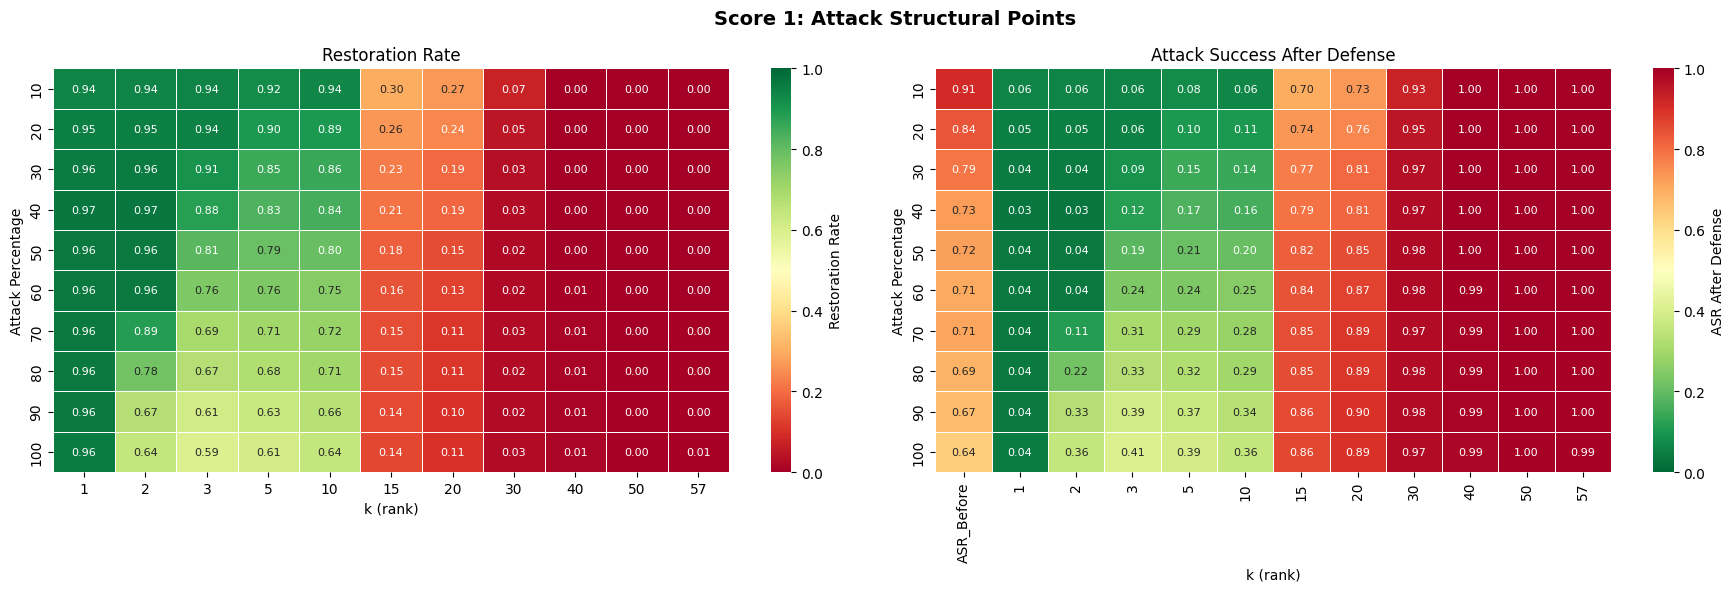

Saved vaccination_score1_noisy.png


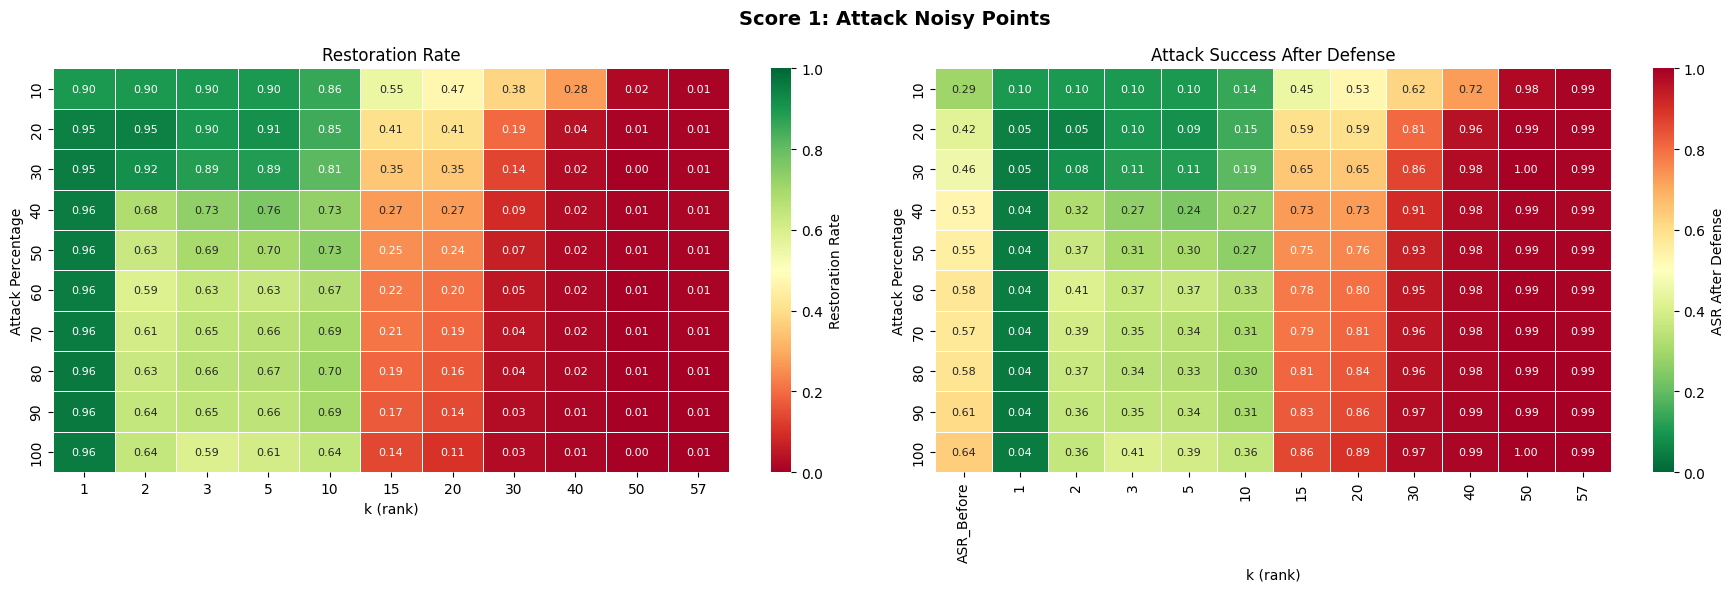

Saved vaccination_score2_structural.png


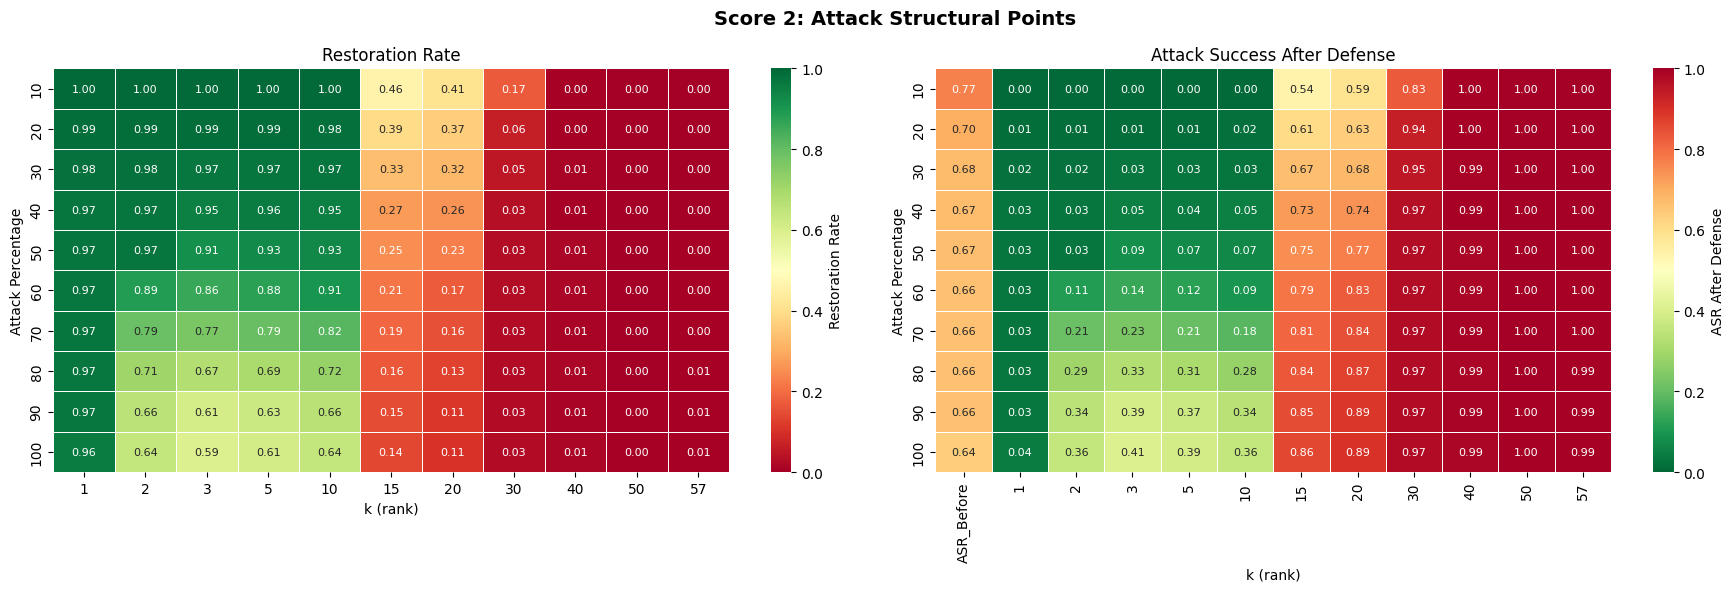

Saved vaccination_score2_noisy.png


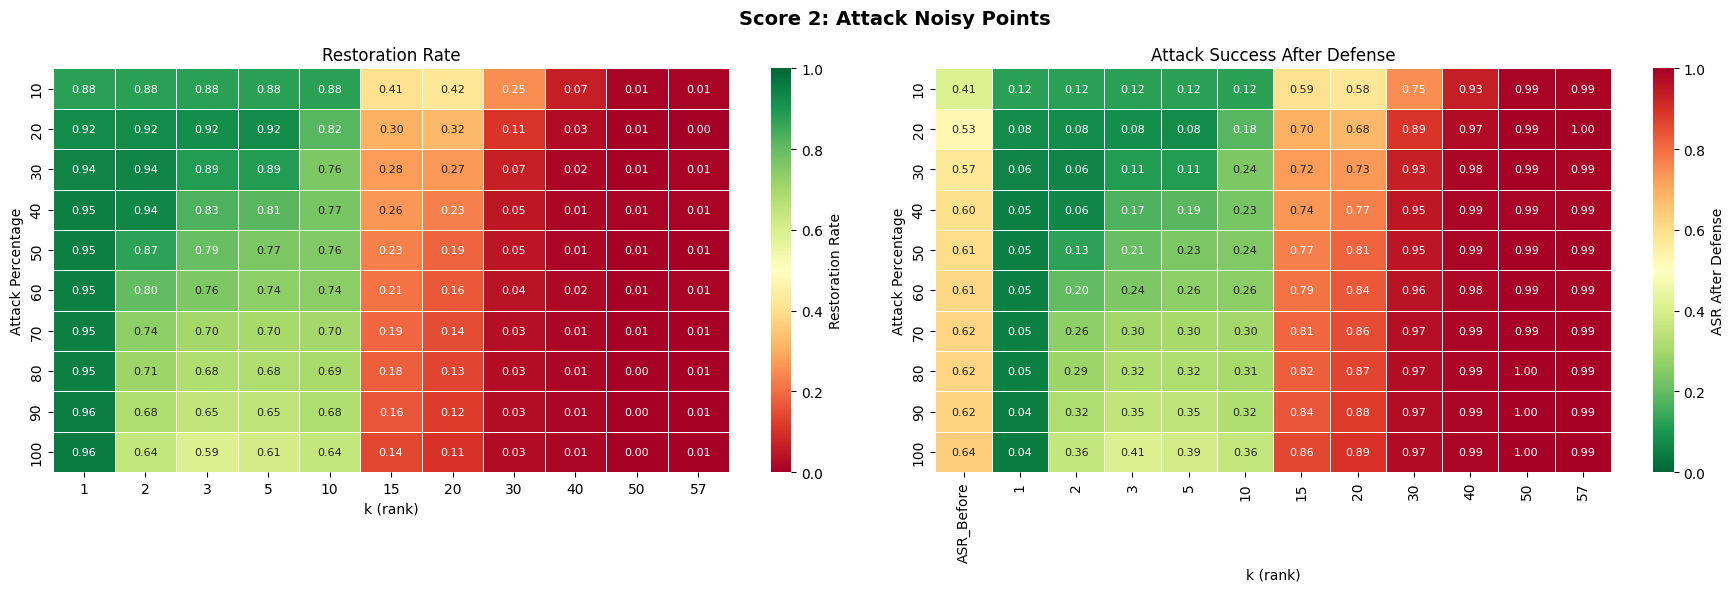

In [98]:
def plot_vaccination_heatmaps(df, score_name, tier_name, output_dir):
    """Produce heatmaps for restoration rate and ASR after defense."""
    sub = df[(df['score_type'] == score_name) & (df['tier'] == tier_name)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Get ASR before vaccination (same for all k values within a score/tier combination)
    asr_before_values = sub.groupby('attack_pct')['asr_before'].first()
    
    fig.suptitle(f'{score_name}: Attack {tier_name.capitalize()} Points', fontsize=14, fontweight='bold')

    # Restoration rate heatmap with ASR before as first column
    pivot_restoration = sub.pivot(index='attack_pct', columns='k', values='restoration_rate')
    pivot_restoration = pivot_restoration.sort_index(ascending=True)
    
    # Add ASR before as a column at the beginning
    pivot_restoration_with_asr = pivot_restoration.copy()
    # pivot_restoration_with_asr.insert(0, 'ASR_Before', [asr_before_values[pct] for pct in pivot_restoration_with_asr.index])
    
    sns.heatmap(
        pivot_restoration_with_asr, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'label': 'Restoration Rate'}
    )
    axes[0].set_title('Restoration Rate')
    axes[0].set_xlabel('k (rank)')
    axes[0].set_ylabel('Attack Percentage')

    # Attack success after defense heatmap with ASR before as first column
    pivot_asr = sub.pivot(index='attack_pct', columns='k', values='asr_after')
    pivot_asr = pivot_asr.sort_index(ascending=True)
    
    # Add ASR before as a column at the beginning
    pivot_asr_with_asr = pivot_asr.copy()
    pivot_asr_with_asr.insert(0, 'ASR_Before', [asr_before_values[pct] for pct in pivot_asr_with_asr.index])
    
    sns.heatmap(
        pivot_asr_with_asr, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r',
        vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'label': 'ASR After Defense'}
    )
    axes[1].set_title('Attack Success After Defense')
    axes[1].set_xlabel('k (rank)')
    axes[1].set_ylabel('Attack Percentage')

    plt.tight_layout()
    fname = f'vaccination_{score_name.lower().replace(" ", "")}_{tier_name}.png'
    fig.savefig(output_dir / fname, dpi=150, bbox_inches='tight')
    print(f'Saved {fname}')
    
    plt.show()


for score_name in score_orders:
    for tier_name in ['structural', 'noisy']:
        plot_vaccination_heatmaps(df, score_name, tier_name, OUTPUT_DIR)


In [80]:
summary = {
    'config': {
        'alpha': ALPHA, 'maxiters': MAXITERS,
        'attack_method': '{ATTACK_METHOD.upper()}',
        'attack_pcts': ATTACK_PCTS, 'k_ranks': K_RANKS,
        'n_test': int(n_test), 'n_correct': int(n_correct),
    },
    'attack_success': {
        '{ATTACK_METHOD.upper()}': int(attack_success[correct_indices].sum())
    },
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All results saved to', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name:45s} ({p.stat().st_size/1024:.1f} KB)')

All results saved to /home/skada009/aro/experiments/final_notebooks/results/taiwan_bankruptcy/pgd_0.07
  adversarial_samples.npz                       (856.2 KB)
  attack_metrics_pgd.txt                        (148.9 KB)
  summary.json                                  (0.5 KB)
  vaccination_score1_noisy.png                  (178.9 KB)
  vaccination_score1_structural.png             (149.7 KB)
  vaccination_score2_noisy.png                  (176.3 KB)
  vaccination_score2_structural.png             (146.1 KB)
  vaccination_sweep.csv                         (31.9 KB)
